In [30]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

import nest_asyncio
nest_asyncio.apply()

import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = "vscode"            

import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
import matplotlib.dates as mdates
plt.style.use('ggplot')
params = {'legend.fontsize': 'x-large',
        'figure.figsize': (12, 8),
        'axes.labelsize': 'x-large',
        'axes.titlesize':'x-large',
        'xtick.labelsize':'x-large',
        'ytick.labelsize':'x-large'}
pylab.rcParams.update(params)

import pandas as pd
import numpy as np
import QuantLib as ql
import rateslib as rl
import datetime
import pytz
NY_tz = pytz.timezone("America/New_York") 
CHI_tz = pytz.timezone("America/Chicago") 
UTC_tz = pytz.timezone("UTC") 

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [31]:
import datetime

from BT.data_handler import TimeGrid
from BT.misc import ql_cal_date_range
from BT.query_actions import AddQueryAction, UnwindPositionsAction
from BT.query_engine import QueryDrivenBacktest
from BT.query_strategy import QueryStrategy
from BT.triggers import DateTrigger, DateTriggerRequirements

from MDP.IRSwaps.IRSwapsMDP import IRSwapsMDP
from TB.IRSwapsTB import IRSwapsTB

from Query.IRSwaps.IRSwapQuery import IRSwapQuery
from Query.IRSwaps.IRSwapStructure import IRSwapStructure
from Query.IRSwaps.IRSwapValue import IRSwapValue

In [32]:
mdp = IRSwapsMDP(source="CME_NY_EOD_LIVE-ql_basic")

# Simple MtM

BACKTESTING...:  25%|██▌       | 1/4 [00:04<00:13,  4.63s/step]

now  2025-09-02 00:00:00
spot starting  3.739907040275465
existing swap (npv and fair coupon ) -2.2351741790771484e-08 3.7399070402754635 September 4th, 2025 September 4th, 2035 0.037399070402754656


BACKTESTING...:  50%|█████     | 2/4 [00:08<00:08,  4.43s/step]

now  2025-09-03 00:00:00
spot starting  3.6789189309728494
existing swap (npv and fair coupon ) 7590.60047134012 3.740663869872582 September 5th, 2025 September 5th, 2035 0.036789189309728555


BACKTESTING...:  75%|███████▌  | 3/4 [00:13<00:04,  4.43s/step]

now  2025-09-04 00:00:00
spot starting  3.6456602054052913
existing swap (npv and fair coupon ) 11627.883145041764 3.741064395103576 September 8th, 2025 September 8th, 2035 0.03645660205405287


BACKTESTING...: 100%|██████████| 4/4 [00:17<00:00,  4.35s/step]

now  2025-09-05 00:00:00
spot starting  3.5638558278789847
existing swap (npv and fair coupon ) 21363.64232365042 3.742024819905463 September 9th, 2025 September 9th, 2035 0.035638558278789846


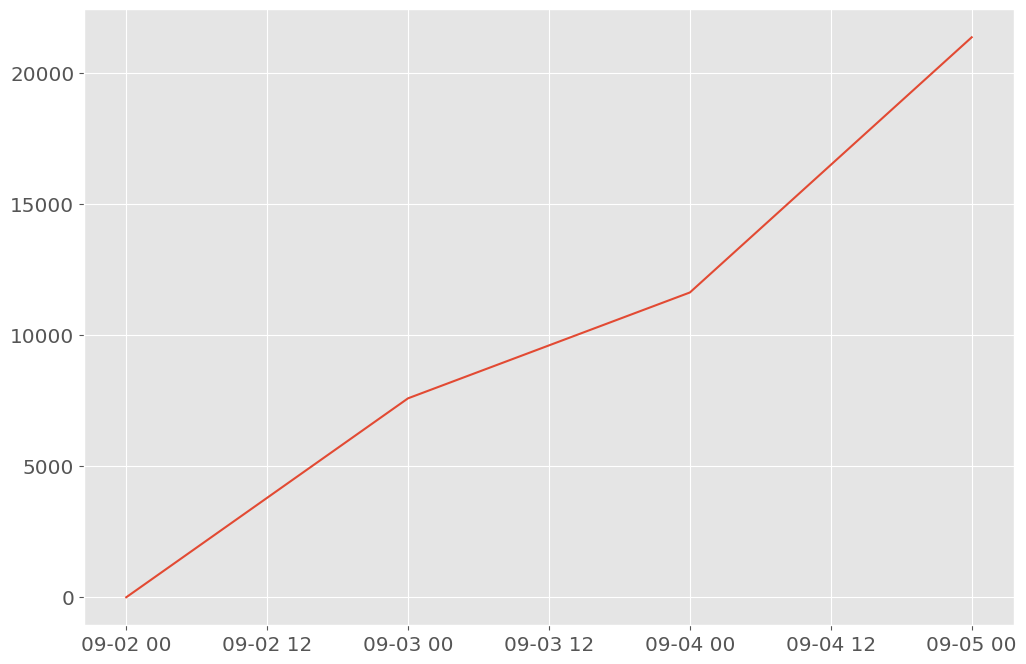

In [35]:
trade_date = datetime.date(2025, 9, 2)

# query = IRSwapQuery(
#     structure=IRSwapStructure.FLY,
#     value=IRSwapValue.NPV,
#     curve="USD-SOFR-1D",
#     structure_kwargs={"front_tenor": "1Yx2Y", "belly_tenor": "1Yx5Y", "back_tenor": "1Yx10Y", "bpv": -100_000},
# )
query = IRSwapQuery(
    tenor="10Y",
    structure=IRSwapStructure.OUTRIGHT,
    value=IRSwapValue.NPV,
    curve="USD-SOFR-1D",
    structure_kwargs={"bpv": 100_000},
)

entry = DateTrigger(DateTriggerRequirements(dates=[trade_date]), actions=[AddQueryAction(query=query)])
# exit_ = DateTrigger(DateTriggerRequirements(dates=[datetime.date(2025, 9, 15)]), actions=[UnwindPositionsAction(match_all=True, fee=0.0)])

tg = TimeGrid(
    ql_cal_date_range(
        ql_cal=ql.UnitedStates(ql.UnitedStates.GovernmentBond),
        start=trade_date,
        end=datetime.date(2025, 9, 5),
    )
)
strategy = QueryStrategy(name=query.col_name(), triggers=[entry])
bt = QueryDrivenBacktest(time_grid=tg, mdp=mdp, strategy=strategy)
bt.run()

mtm = pd.Series(bt.mtm_history).sort_index()
plt.plot(mtm)

Ignoring index for C:\Users\chris\AppData\Local\ARBS\Cache\zodb\dump\IRSwapsTB_v2_CME_NY_EOD_LIVE-ql_basic.fs


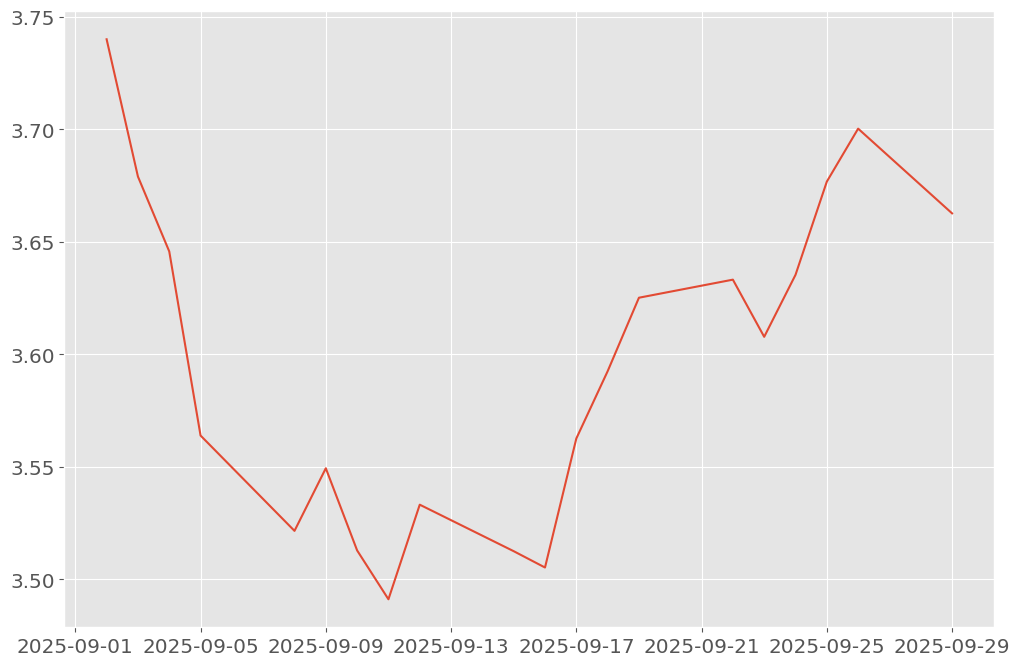

In [6]:
tb = IRSwapsTB(mdp=mdp)
q = IRSwapQuery(curve="USD-SOFR-1D", tenor="10Y", structure_kwargs={"bpv": 1})
df = tb.get_timeseries(start=datetime.date(2025, 9, 1), end=datetime.date(2025, 9, 29), queries=[q], n_jobs=1)
plt.plot(df.index, df[q.col_name()])

In [10]:
df

,USD-SOFR-1D 10Y REC 0.0k/bp OUTRIGHT RATE
Date,
2025-09-02,3.739907
2025-09-03,3.678919
2025-09-04,3.645660
2025-09-05,3.563856
2025-09-08,3.521508
2025-09-09,3.549320
2025-09-10,3.512818
2025-09-11,3.491114
2025-09-12,3.533141
